In [1]:
from pathlib import Path

import pandas as pd
from tqdm import tqdm

In [2]:
DATA_DIR = Path("output")
CSV_PATTERN = "dataset_winsize*_when.csv"

OUTPUT_DIR = Path("model_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
DEVICE = "cuda:0"

DROP_COLUMNS = [
    "fold_id",
    "label_is_auto",
    "label_time_to_event_seconds",
    "label_from_zone",
    "label_to_zone",
]

REGRESSION_SUMMARY_FILENAME = "regression_summary_XGBoost.csv"

In [3]:
csv_files = sorted(
    DATA_DIR.glob(CSV_PATTERN),
    key=lambda p: float(p.stem.split("winsize", 1)[1].removesuffix("h_when")),
)
csv_file_path = csv_files[4]

csv_file_path, csv_files

(PosixPath('output/dataset_winsize3h_when.csv'),
 [PosixPath('output/dataset_winsize0.25h_when.csv'),
  PosixPath('output/dataset_winsize0.5h_when.csv'),
  PosixPath('output/dataset_winsize1h_when.csv'),
  PosixPath('output/dataset_winsize2h_when.csv'),
  PosixPath('output/dataset_winsize3h_when.csv'),
  PosixPath('output/dataset_winsize4h_when.csv'),
  PosixPath('output/dataset_winsize5h_when.csv'),
  PosixPath('output/dataset_winsize6h_when.csv'),
  PosixPath('output/dataset_winsize7h_when.csv'),
  PosixPath('output/dataset_winsize8h_when.csv'),
  PosixPath('output/dataset_winsize9h_when.csv'),
  PosixPath('output/dataset_winsize10h_when.csv'),
  PosixPath('output/dataset_winsize11h_when.csv'),
  PosixPath('output/dataset_winsize12h_when.csv')])

In [4]:
df = pd.read_csv(csv_file_path)

print(f"\nReading {csv_file_path}")


Reading output/dataset_winsize3h_when.csv


# train xgboost models for each window size

In [5]:
import numpy as np
from xgboost import XGBRegressor

TRAIN_FOLDS = [0, 1, 2, 3, 4]
TEST_FOLD = -1
regression_target = "label_time_to_event_seconds"


def _as_numpy(values):
    if hasattr(values, "get") and not isinstance(values, (pd.Series, pd.DataFrame)):
        values = values.get()
    return np.asarray(values, dtype=float)


def mae_loss(y_true, y_pred):
    return float(np.mean(np.abs(_as_numpy(y_true) - _as_numpy(y_pred))))


xgboost_window_models = []
xgboost_window_test_losses = []

for dataset_path in tqdm(csv_files):
    dataset_df = pd.read_csv(dataset_path)
    train_df = dataset_df[dataset_df["fold_id"].isin(TRAIN_FOLDS)].copy()
    test_df = dataset_df[dataset_df["fold_id"] == TEST_FOLD].copy()

    X_train = train_df.drop(columns=DROP_COLUMNS, errors="ignore")
    X_train = X_train.select_dtypes(include=["number", "bool"])
    y_train = train_df[regression_target].astype(float)
    train_mask = y_train.notna()
    X_train = X_train.loc[train_mask]
    y_train = y_train.loc[train_mask]

    X_test = test_df.drop(columns=DROP_COLUMNS, errors="ignore")
    X_test = X_test.select_dtypes(include=["number", "bool"])
    y_test = test_df[regression_target].astype(float)
    test_mask = y_test.notna()
    X_test = X_test.loc[test_mask]
    y_test = y_test.loc[test_mask]

    model = XGBRegressor(
        objective="reg:absoluteerror",
        eval_metric="mae",
        tree_method="hist",
        device=DEVICE,
        n_jobs=1,
        random_state=RANDOM_STATE,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        # colsample_bytree=0.8,
        # reg_lambda=1.0,
        # base_score=float(y_train.median()),
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    test_loss = mae_loss(y_test, y_pred)

    xgboost_window_models.append(model)
    xgboost_window_test_losses.append(test_loss)

    print(f"{dataset_path.name}: test MAE={test_loss:.6f}")

xgboost_window_test_losses

  0%|          | 0/14 [00:00<?, ?it/s]/home/aj/venv/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [03:02:40] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
  7%|▋         | 1/14 [00:00<00:10,  1.24it/s]

dataset_winsize0.25h_when.csv: test MAE=4940.481670


 14%|█▍        | 2/14 [00:01<00:07,  1.54it/s]

dataset_winsize0.5h_when.csv: test MAE=4931.934728


 21%|██▏       | 3/14 [00:01<00:06,  1.62it/s]

...

 93%|█████████▎| 13/14 [00:07<00:00,  1.77it/s]

dataset_winsize11h_when.csv: test MAE=4966.617075


100%|██████████| 14/14 [00:08<00:00,  1.72it/s]

dataset_winsize12h_when.csv: test MAE=5005.492801


[4940.481670280846,
 4931.934727769945,
 4920.4970028016005,
 4895.665070880325,
 4892.4040849601215,
 4872.482538540361,
 4851.429432651453,
 4903.505509276936,
 4887.519915919355,
 4898.944522357326,
 4953.2122496793745,
 4913.0972369073725,
 4966.617075015827,
 5005.492800808988]

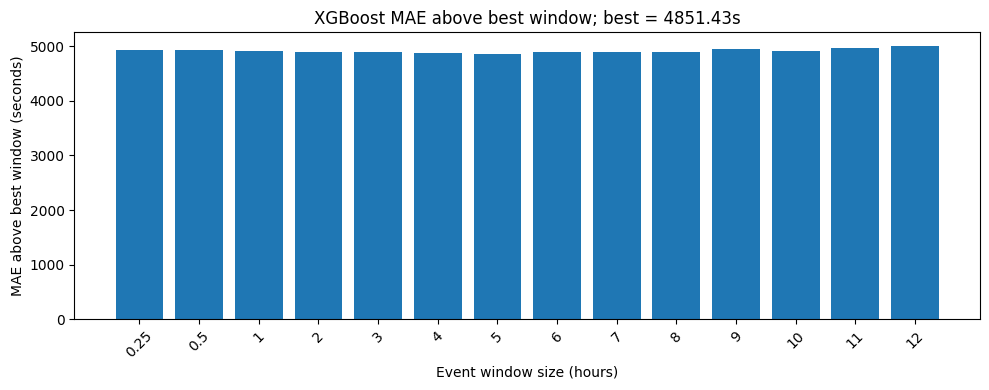

In [8]:
import matplotlib.pyplot as plt

window_sizes = [
    path.stem.split("winsize", 1)[1].removesuffix("h_when") for path in csv_files
]

plt.figure(figsize=(10, 4))
plt.bar(window_sizes, xgboost_window_test_losses)
plt.xlabel("Event window size (hours)")
plt.ylabel("MAE above best window (seconds)")
plt.title(f"XGBoost MAE above best window; best = {best_loss:.2f}s")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

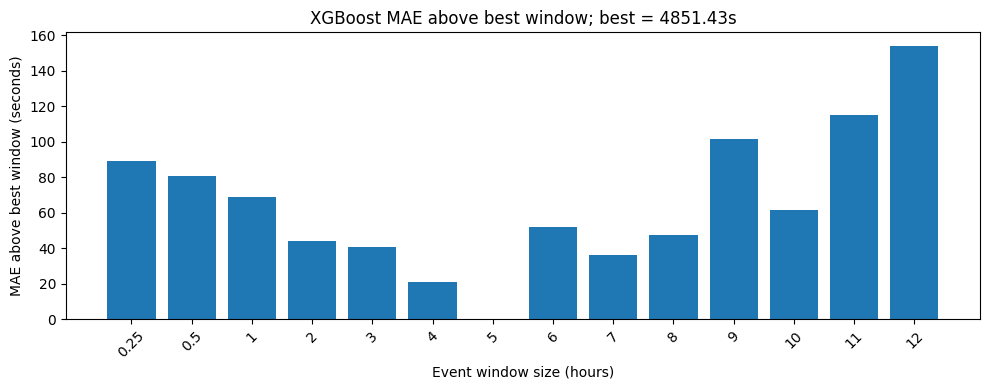

In [ ]:
best_loss = min(xgboost_window_test_losses)
loss_above_best = [loss - best_loss for loss in xgboost_window_test_losses]

plt.figure(figsize=(10, 4))
plt.bar(window_sizes, loss_above_best)
plt.xlabel("Event window size (hours)")
plt.ylabel("MAE above best window (seconds)")
plt.title(f"XGBoost MAE above best window; best = {best_loss:.2f}s")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

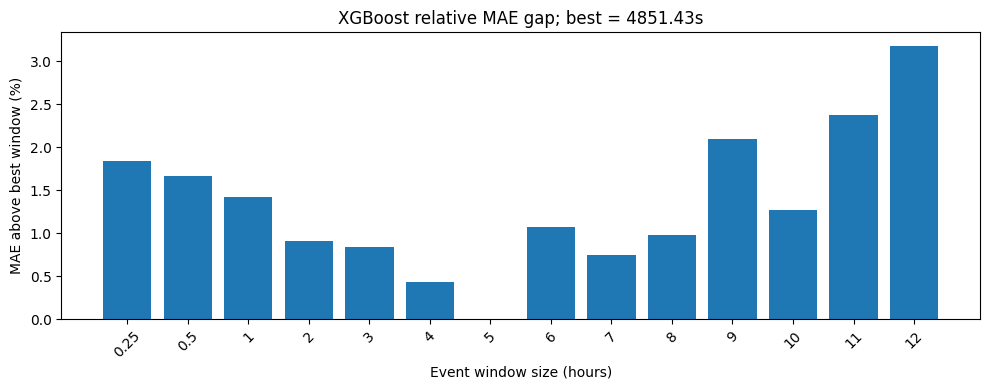